In [8]:
G = [
    [0, 1, 1, 0, 1, 0],
    [1, 0, 1, 1, 0, 1],
    [1, 1, 0, 1, 1, 0],
    [0, 1, 1, 0, 0, 1],
    [1, 0, 1, 0, 0, 1],
    [0, 1, 0, 1, 1, 0]
]

node = "ABCDEF"  # sửa lại đủ 6 đỉnh

t_ = {}
for i in range(len(G)):
    t_[node[i]] = i

# Tính bậc đỉnh
degree = []
for i in range(len(G)):
    degree.append(sum(G[i]))

# Tập màu
ColorDict = {}
for i in range(len(G)):
    ColorDict[node[i]] = ["Blue", "Red", "Yellow", "Green"]

# Sắp xếp đỉnh theo bậc giảm dần
sortNode = []
indeks = []

for i in range(len(G)):
    max_val = -1
    index = -1
    for j in range(len(degree)):
        if j not in indeks:
            if degree[j] > max_val:
                max_val = degree[j]
                index = j
    indeks.append(index)
    sortNode.append(node[index])

# Tô màu
TheSolution = {}

for n in sortNode:
    for color in ColorDict[n]:
        conflict = False
        adjacentNode = G[t_[n]]

        for j in range(len(adjacentNode)):
            if adjacentNode[j] == 1 and node[j] in TheSolution:
                if TheSolution[node[j]] == color:
                    conflict = True
                    break

        if not conflict:
            TheSolution[n] = color
            break

# In kết quả
for t, w in sorted(TheSolution.items()):
    print("Đỉnh", t, "=", w)

Đỉnh A = Yellow
Đỉnh B = Blue
Đỉnh C = Red
Đỉnh D = Yellow
Đỉnh E = Blue
Đỉnh F = Red


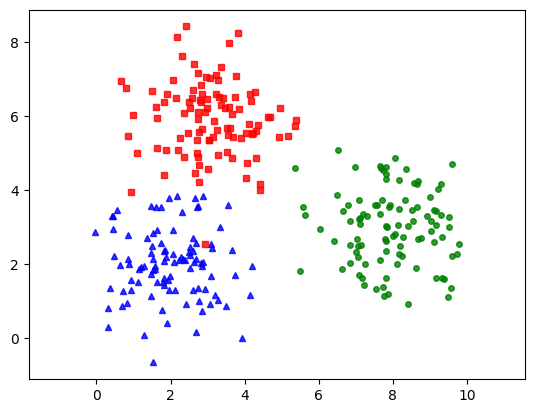

In [16]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

np.random.seed(11)

means = [[2, 2], [8, 3], [3, 6]]
cov = [[1, 0], [0, 1]]
N = 100

X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)

X = np.concatenate((X0, X1, X2), axis=0)
K = 3

original_label = np.asarray([0]*N + [1]*N + [2]*N)

# sửa lỗi "ef" -> "def"
def kmeans_display(X, label):
    X0 = X[label == 0, :]
    X1 = X[label == 1, :]
    X2 = X[label == 2, :]

    plt.plot(X0[:, 0], X0[:, 1], 'b^', markersize=4, alpha=.8)
    plt.plot(X1[:, 0], X1[:, 1], 'go', markersize=4, alpha=.8)
    plt.plot(X2[:, 0], X2[:, 1], 'rs', markersize=4, alpha=.8)

    plt.axis('equal')
    plt.show()

kmeans_display(X, original_label)

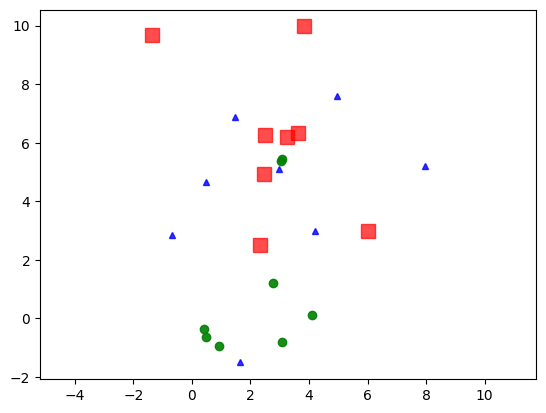

In [32]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

np.random.seed(11)

# ===== 1. Tạo dữ liệu =====
trung_tam = [[3, 6], [1, 1], [3, 6]] # Tâm cụm theo x và y0
hiep_phuong_sai = [[8, 0], [0, 8]] # Kéo giãn
so_diem = 8 # Số điểm mỗi cụm

cum0 = np.random.multivariate_normal(trung_tam[0], hiep_phuong_sai, so_diem)
cum1 = np.random.multivariate_normal(trung_tam[1], hiep_phuong_sai, so_diem)
cum2 = np.random.multivariate_normal(trung_tam[2], hiep_phuong_sai, so_diem)

du_lieu = np.concatenate((cum0, cum1, cum2), axis=0)
so_cum = 3

# Nhãn đúng ban đầu
nhan_goc = np.asarray([0]*so_diem + [1]*so_diem + [2]*so_diem)

# ===== 2. Hàm hiển thị =====
def hien_thi_kmeans(du_lieu, nhan):
    cum0 = du_lieu[nhan == 0, :]
    cum1 = du_lieu[nhan == 1, :]
    cum2 = du_lieu[nhan == 2, :]

    plt.plot(cum0[:, 0], cum0[:, 1], 'b^', markersize=5, alpha=.8)
    plt.plot(cum1[:, 0], cum1[:, 1], 'go', markersize=6, alpha=.9)
    plt.plot(cum2[:, 0], cum2[:, 1], 'rs', markersize=10, alpha=.7)

    plt.axis('equal')
    plt.show()

# ===== 3. Gọi hàm hiển thị =====
hien_thi_kmeans(du_lieu, nhan_goc)

In [35]:
import sys

VO_CUC = sys.maxsize

# ===== 1. Ma trận chi phí =====
chi_phi = [
    [0, 10, 15, 20],
    [10, 0, 35, 25],
    [15, 35, 0, 30],
    [20, 25, 30, 0]
]

so_thanh_pho = len(chi_phi)

# ===== 2. Biến toàn cục =====
da_tham = [False] * so_thanh_pho
duong_di = [0] * so_thanh_pho
chi_phi_tot_nhat = VO_CUC
duong_di_tot_nhat = []

# ===== 3. Thuật toán TSP (quay lui + cận) =====
def nguoi_ban_hang(i, chi_phi_hien_tai):
    global chi_phi_tot_nhat, duong_di_tot_nhat

    # nếu đã đi hết thành phố
    if i == so_thanh_pho:
        tong_chi_phi = chi_phi_hien_tai + chi_phi[duong_di[i-1]][duong_di[0]]

        if tong_chi_phi < chi_phi_tot_nhat:
            chi_phi_tot_nhat = tong_chi_phi
            duong_di_tot_nhat = duong_di.copy()
        return

    # thử các thành phố tiếp theo
    for j in range(so_thanh_pho):
        if not da_tham[j]:

            chi_phi_moi = chi_phi_hien_tai + chi_phi[duong_di[i-1]][j]

            # cắt nhánh
            if chi_phi_moi < chi_phi_tot_nhat:
                duong_di[i] = j
                da_tham[j] = True

                nguoi_ban_hang(i + 1, chi_phi_moi)

                da_tham[j] = False

# ===== 4. Khởi tạo =====
da_tham[0] = True
duong_di[0] = 0

# ===== 5. Chạy thuật toán =====
nguoi_ban_hang(1, 0)

# ===== 6. In kết quả =====
print("Chu trình tối ưu:")

for tp in duong_di_tot_nhat:
    print(tp, end=" -> ")

print(duong_di_tot_nhat[0])

print("Chi phí nhỏ nhất:", chi_phi_tot_nhat)

Chu trình tối ưu:
0 -> 1 -> 3 -> 2 -> 0
Chi phí nhỏ nhất: 80
